# Produced Subdatabases & Information

In [43]:
import pandas as pd

## Subdatabases

During preprocessing, we were able to split the database into four sub-databases each with their own purpose.

### Binding Labels

`01_binding_labels.csv` - A label file used to categorize specific protein binders. Each row represents a unique antibody or nanobody, identified by an id and a name. The dataset includes the following binary flags (0 or 1):

- `is_binding_SARS-CoV2_WT`: Indicates if the sequence binds to the Wild Type SARS-CoV-2.

- `is_neutral_SARS-CoV2_WT`: Indicates if the sequence has neutralizing activity against the Wild Type.

- `is_nanobody`: Distinguishes between nanobodies (1) and standard antibodies (0).

In [44]:
binding_labels = pd.read_csv('../p03_preprocessing/data/01_binding_labels.csv')
binding_labels = binding_labels.rename(columns={'Unnamed: 0': 'id'})
binding_labels.head()

,id,is_binding_SARS-CoV2_WT,is_neutral_SARS-CoV2_WT,is_nanobody,name
0,0,1,1,0,Curtis_3548_S-2
1,1,1,0,0,Curtis_3548_S-7
2,2,1,0,0,Curtis_3548_RBD-15
3,3,1,1,0,8-D9
4,4,1,1,0,Sun_1G11


In [45]:
binding_labels.shape

(17918, 5)

### Naive Processed Features

`02_naive_processed_features.csv` — A comprehensive feature set containing 92 columns for each binder. It includes:

- Structural Features: Lengths and normalized amino-acid percentages for four key regions: `CDRH3`, `CDRL3`, `VL`, and `VHorVHH`.

- Target Identifiers: Binary flags indicating which antigens or protein subunits the binder was tested against, including `S_RBD`, `S_NTD`, `S_S2`, `S_S1`, and `N_Protein`.

- Metadata: A unique id for joining with the binding_labels.csv.

Each feature group = length + 21 amino acid percentages

In [46]:
naive_processed_features = pd.read_csv('../p03_preprocessing/data/02_naive_processed_features.csv')
naive_processed_features = naive_processed_features.rename(columns={'Unnamed: 0': 'id'})
naive_processed_features.head()

,id,CDRH3_len,CDRH3_amino_acid_percentage_A,CDRH3_amino_acid_percentage_C,CDRH3_amino_acid_percentage_D,CDRH3_amino_acid_percentage_E,CDRH3_amino_acid_percentage_F,CDRH3_amino_acid_percentage_G,CDRH3_amino_acid_percentage_H,CDRH3_amino_acid_percentage_I,...,VHorVHH_amino_acid_percentage_V,VHorVHH_amino_acid_percentage_W,VHorVHH_amino_acid_percentage_Y,S_RBD,S_NTD,S_S2,S_S1,N_Protein,Other_Spike,Unknown
0,0,13,0.076923,0.0,0.230769,0.000000,0.076923,0.076923,0.000000,0.000000,...,0.000000,0.000000,0.000000,1,0,0,0,0,0,0
1,1,14,0.071429,0.0,0.071429,0.071429,0.000000,0.214286,0.000000,0.000000,...,0.000000,0.000000,0.000000,1,0,0,0,0,0,0
2,2,14,0.071429,0.0,0.000000,0.000000,0.071429,0.142857,0.000000,0.071429,...,0.000000,0.000000,0.000000,1,0,0,0,0,0,0
3,3,11,0.181818,0.0,0.181818,0.000000,0.000000,0.090909,0.181818,0.090909,...,0.095652,0.026087,0.052174,1,0,0,0,0,0,0
4,4,18,0.000000,0.0,0.166667,0.000000,0.055556,0.055556,0.000000,0.055556,...,0.080000,0.032000,0.064000,1,0,0,0,0,0,0


In [47]:
naive_processed_features.shape

(17918, 92)

### CTD Processed Features

`03_conjoint_triads_processed_features.csv` — A high-dimensional feature table capturing local sequence context for each binder. Instead of global scales, it uses Conjoint Triad Descriptors (CTD) to represent CDRH3, CDRL3, VL, and VHorVHH.

- The Method: Amino acids are mapped to 7 physicochemical classes (Aliphatic, Polar, Charged, etc.). Features are calculated based on the frequency of every possible 3-residue combination (e.g., CTD_111 to CTD_777).

In [48]:
conjoint_triads_processed_features = pd.read_csv('../p03_preprocessing/data/03_conjoint_triads_processed_features.csv')
conjoint_triads_processed_features = conjoint_triads_processed_features.rename(columns={'Unnamed: 0': 'id'})
conjoint_triads_processed_features.head()

,id,name,CDRH3_CTD_111,CDRH3_CTD_112,CDRH3_CTD_113,CDRH3_CTD_114,CDRH3_CTD_115,CDRH3_CTD_116,CDRH3_CTD_117,CDRH3_CTD_121,...,VHorVHH_CTD_765,VHorVHH_CTD_766,VHorVHH_CTD_767,VHorVHH_CTD_771,VHorVHH_CTD_772,VHorVHH_CTD_773,VHorVHH_CTD_774,VHorVHH_CTD_775,VHorVHH_CTD_776,VHorVHH_CTD_777
0,0,Curtis_3548_S-2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,Curtis_3548_S-7,0.0,0.0,0.0,0.0,0.083333,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,Curtis_3548_RBD-15,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,8-D9,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,Sun_1G11,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
conjoint_triads_processed_features.shape

(17918, 1374)

In [50]:
list(conjoint_triads_processed_features.columns)

['id',
 'name',
 'CDRH3_CTD_111',
 'CDRH3_CTD_112',
 'CDRH3_CTD_113',
 'CDRH3_CTD_114',
 'CDRH3_CTD_115',
 'CDRH3_CTD_116',
 'CDRH3_CTD_117',
 'CDRH3_CTD_121',
 'CDRH3_CTD_122',
 'CDRH3_CTD_123',
 'CDRH3_CTD_124',
 'CDRH3_CTD_125',
 'CDRH3_CTD_126',
 'CDRH3_CTD_127',
 'CDRH3_CTD_131',
 'CDRH3_CTD_132',
 'CDRH3_CTD_133',
 'CDRH3_CTD_134',
 'CDRH3_CTD_135',
 'CDRH3_CTD_136',
 'CDRH3_CTD_137',
 'CDRH3_CTD_141',
 'CDRH3_CTD_142',
 'CDRH3_CTD_143',
 'CDRH3_CTD_144',
 'CDRH3_CTD_145',
 'CDRH3_CTD_146',
 'CDRH3_CTD_147',
 'CDRH3_CTD_151',
 'CDRH3_CTD_152',
 'CDRH3_CTD_153',
 'CDRH3_CTD_154',
 'CDRH3_CTD_155',
 'CDRH3_CTD_156',
 'CDRH3_CTD_157',
 'CDRH3_CTD_161',
 'CDRH3_CTD_162',
 'CDRH3_CTD_163',
 'CDRH3_CTD_164',
 'CDRH3_CTD_165',
 'CDRH3_CTD_166',
 'CDRH3_CTD_167',
 'CDRH3_CTD_171',
 'CDRH3_CTD_172',
 'CDRH3_CTD_173',
 'CDRH3_CTD_174',
 'CDRH3_CTD_175',
 'CDRH3_CTD_176',
 'CDRH3_CTD_177',
 'CDRH3_CTD_211',
 'CDRH3_CTD_212',
 'CDRH3_CTD_213',
 'CDRH3_CTD_214',
 'CDRH3_CTD_215',
 'CDRH3_CTD_

### Physicochemical Properties

`04_antibody_only_physicochemical_properties.csv` — A table of calculated biophysical properties for each of the four key regions (CDRH3, CDRL3, VL, and VHorVHH). Every row represents a binder and includes exactly nine numerical statistics per region:

- Hydrophobicity & Aliphatic Index: Metrics for the sequence's water-solubility and relative volume occupied by aliphatic side chains.

- Isoelectric Point (pI) & Charge at pH 7: Measures of the net electrical charge, critical for understanding binding affinity.

- Molecular Weight: The total mass of the specific loop/chain.

- Instability & Flexibility: Predicted structural stability and the mean flexibility of the amino acid residues.

- Aromaticity & Boman Index: The frequency of aromatic residues and a metric for the potential of the protein to interact with other proteins (protein-binding potential).

In [51]:
antibody_only_physicochemical_properties = pd.read_csv('../p03_preprocessing/data/04_antibody_only_physicochemical_properties.csv')
antibody_only_physicochemical_properties = antibody_only_physicochemical_properties.rename(columns={'Unnamed: 0': 'id'})
antibody_only_physicochemical_properties.head()

,id,CDRH3_hydrophobicity,CDRH3_isoelectric_point,CDRH3_charge_ph7,CDRH3_molecular_weight,CDRH3_aliphatic_index,CDRH3_instability_index,CDRH3_aromaticity,CDRH3_boman_index,CDRH3_flexibility,...,VL_flexibility,VHorVHH_hydrophobicity,VHorVHH_isoelectric_point,VHorVHH_charge_ph7,VHorVHH_molecular_weight,VHorVHH_aliphatic_index,VHorVHH_instability_index,VHorVHH_aromaticity,VHorVHH_boman_index,VHorVHH_flexibility
0,0,-1.661538,6.516511,-0.006719,1584.66824,37.692308,45.515385,0.153846,5.419231,0.313815,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
1,1,-1.378571,6.482197,-0.008492,1545.64654,7.142857,45.614286,0.142857,3.247857,0.364631,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
2,2,-0.278571,9.145600,0.989899,1549.70264,35.000000,31.021429,0.285714,0.393571,0.358007,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
3,3,-0.654545,6.498637,-0.928173,1191.26864,89.090909,9.090909,0.000000,2.789091,0.180587,...,0.915322,-0.165217,8.204080,0.775477,12428.90994,75.391304,39.674087,0.104348,1.387478,0.917896
4,4,-0.905556,3.826102,-2.011701,2114.20904,59.444444,46.888889,0.222222,2.469444,0.503837,...,0.913088,-0.332000,5.815560,-1.268049,13760.24904,69.360000,41.116080,0.136000,1.558400,0.927044


In [52]:
antibody_only_physicochemical_properties.shape

(17918, 37)

In [53]:
list(antibody_only_physicochemical_properties.columns)

['id',
 'CDRH3_hydrophobicity',
 'CDRH3_isoelectric_point',
 'CDRH3_charge_ph7',
 'CDRH3_molecular_weight',
 'CDRH3_aliphatic_index',
 'CDRH3_instability_index',
 'CDRH3_aromaticity',
 'CDRH3_boman_index',
 'CDRH3_flexibility',
 'CDRL3_hydrophobicity',
 'CDRL3_isoelectric_point',
 'CDRL3_charge_ph7',
 'CDRL3_molecular_weight',
 'CDRL3_aliphatic_index',
 'CDRL3_instability_index',
 'CDRL3_aromaticity',
 'CDRL3_boman_index',
 'CDRL3_flexibility',
 'VL_hydrophobicity',
 'VL_isoelectric_point',
 'VL_charge_ph7',
 'VL_molecular_weight',
 'VL_aliphatic_index',
 'VL_instability_index',
 'VL_aromaticity',
 'VL_boman_index',
 'VL_flexibility',
 'VHorVHH_hydrophobicity',
 'VHorVHH_isoelectric_point',
 'VHorVHH_charge_ph7',
 'VHorVHH_molecular_weight',
 'VHorVHH_aliphatic_index',
 'VHorVHH_instability_index',
 'VHorVHH_aromaticity',
 'VHorVHH_boman_index',
 'VHorVHH_flexibility']

## Exploratory Data Analysis (IGNORE)

Let's first import necessary libraries

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

Load all data from earlier

In [ ]:
path_prefix = '../p03_preprocessing/data/'
labels = pd.read_csv(f'{path_prefix}01_binding_labels.csv', index_col=0)
naive_features = pd.read_csv(f'{path_prefix}02_naive_processed_features.csv', index_col=0)
conjoint_triads = pd.read_csv(f'{path_prefix}03_conjoint_triads_processed_features.csv', index_col=0)
global_features = pd.read_csv(f'{path_prefix}04_antibody_only_physicochemical_properties.csv', index_col=0)

Merge them into a single DF

In [71]:
df = labels.join(naive_features.drop(columns=['id'], errors='ignore'), how='inner')
df = df.join(global_features.drop(columns=['id'], errors='ignore'), how='inner')
df.head(10)

,is_binding_SARS-CoV2_WT,is_neutral_SARS-CoV2_WT,is_nanobody,name,CDRH3_len,CDRH3_amino_acid_percentage_A,CDRH3_amino_acid_percentage_C,CDRH3_amino_acid_percentage_D,CDRH3_amino_acid_percentage_E,CDRH3_amino_acid_percentage_F,...,VL_flexibility,VHorVHH_hydrophobicity,VHorVHH_isoelectric_point,VHorVHH_charge_ph7,VHorVHH_molecular_weight,VHorVHH_aliphatic_index,VHorVHH_instability_index,VHorVHH_aromaticity,VHorVHH_boman_index,VHorVHH_flexibility
0,1,1,0,Curtis_3548_S-2,13,0.076923,0.000,0.230769,0.000000,0.076923,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
1,1,0,0,Curtis_3548_S-7,14,0.071429,0.000,0.071429,0.071429,0.000000,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
2,1,0,0,Curtis_3548_RBD-15,14,0.071429,0.000,0.000000,0.000000,0.071429,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
3,1,1,0,8-D9,11,0.181818,0.000,0.181818,0.000000,0.000000,...,0.915322,-0.165217,8.204080,0.775477,12428.90994,75.391304,39.674087,0.104348,1.387478,0.917896
4,1,1,0,Sun_1G11,18,0.000000,0.000,0.166667,0.000000,0.055556,...,0.913088,-0.332000,5.815560,-1.268049,13760.24904,69.360000,41.116080,0.136000,1.558400,0.927044
5,1,2,1,8F4P,10,0.100000,0.000,0.200000,0.100000,0.100000,...,NaN,-0.214530,4.725068,-2.297467,12293.67124,65.897436,33.538462,0.102564,1.239829,0.927000
6,1,1,0,NIV-1,12,0.166667,0.000,0.083333,0.000000,0.000000,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
7,1,1,0,NIV-5,16,0.187500,0.125,0.062500,0.000000,0.062500,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
8,1,1,0,NIV-6,14,0.000000,0.000,0.071429,0.071429,0.142857,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000
9,1,1,0,NIV-8,18,0.111111,0.000,0.166667,0.000000,0.111111,...,0.000000,-3.500000,3.749987,-1.004916,247.20764,0.000000,5.000000,0.000000,7.680000,0.000000


In [72]:
df['is_binding_SARS-CoV2_WT'].value_counts()

is_binding_SARS-CoV2_WT
1    11267
0     5629
2     1022
Name: count, dtype: int64

In [74]:
df['is_neutral_SARS-CoV2_WT'].value_counts()

is_neutral_SARS-CoV2_WT
0    8059
1    5563
2    4296
Name: count, dtype: int64

### Labels

Let's first check the ratio of `is_binding` vs. `is_neutral`. Neutralizers are usually a subset of binders.

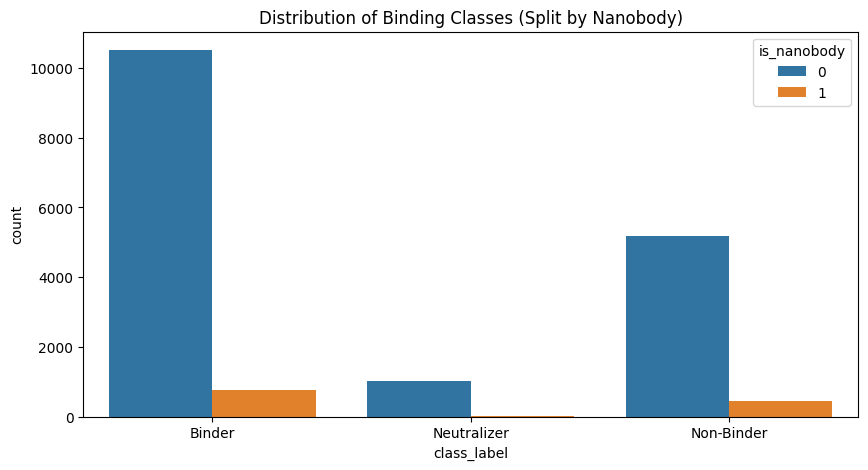

In [69]:
class_map = {0: 'Non-Binder', 1: 'Binder', 2: 'Neutralizer'}
df['class_label'] = df['is_binding_SARS-CoV2_WT'].map(class_map)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='class_label', hue='is_nanobody')
plt.title('Distribution of Binding Classes (Split by Nanobody)')
plt.show()

In [ ]:
# 2. Merge on ID (Assuming index is already 'id' or unnamed: 0)
# If 'id' is a column, use: df_eda = pd.merge(labels, global_features, on='id')
df_eda = labels.join(global_features, how='inner')

# Define the target and the features we want to inspect
target = 'is_binding_SARS-CoV2_WT'
phys_cols = [
    'CDRH3_hydrophobicity', 'CDRH3_isoelectric_point', 
    'CDRH3_charge_ph7', 'CDRH3_molecular_weight', 
    'CDRH3_aliphatic_index', 'CDRH3_instability_index', 
    'CDRH3_aromaticity', 'CDRH3_boman_index', 'CDRH3_flexibility'
]

In [61]:
df_eda.shape

(17918, 40)

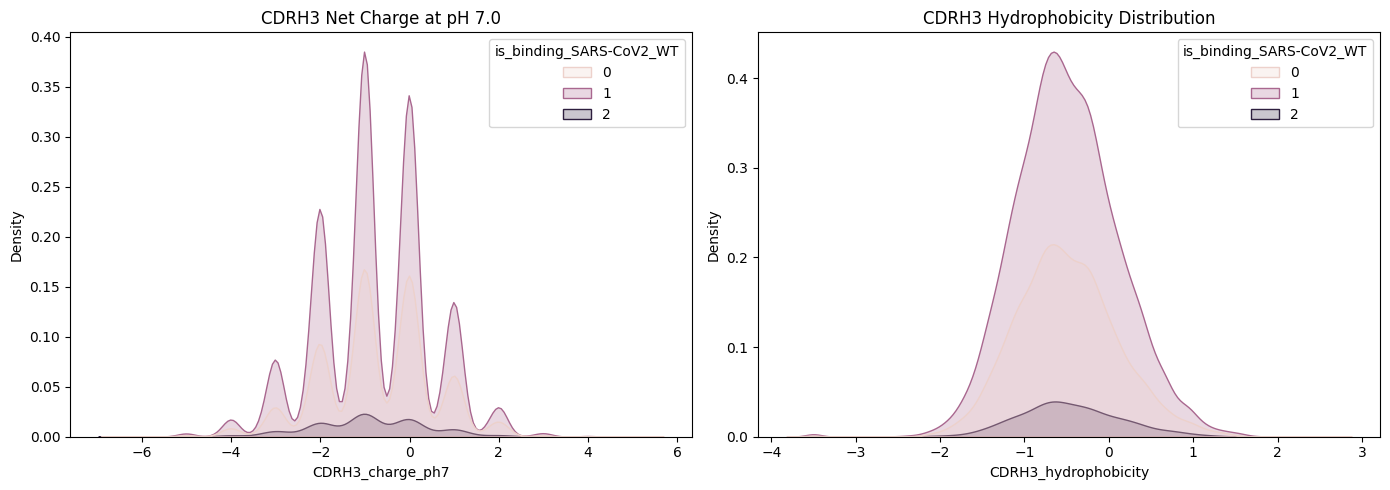

In [56]:
# 3. Plot Distributions for Charge and Hydrophobicity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df_eda, x='CDRH3_charge_ph7', hue=target, fill=True, ax=axes[0])
axes[0].set_title('CDRH3 Net Charge at pH 7.0')

sns.kdeplot(data=df_eda, x='CDRH3_hydrophobicity', hue=target, fill=True, ax=axes[1])
axes[1].set_title('CDRH3 Hydrophobicity Distribution')

plt.tight_layout()
plt.show()

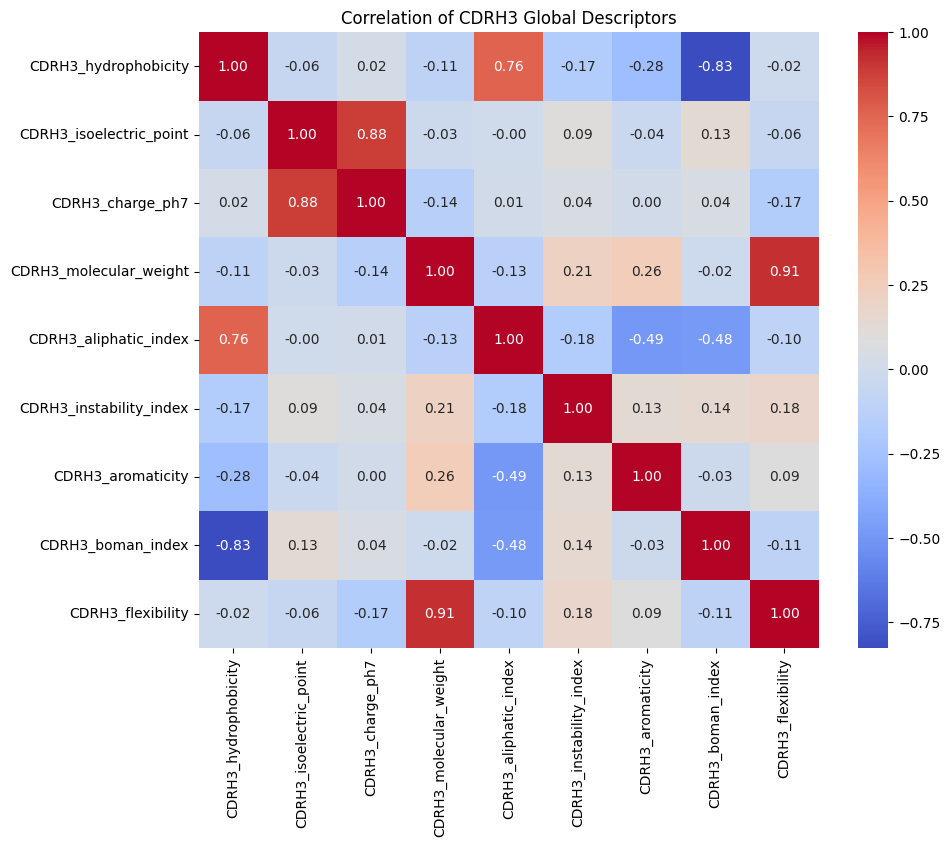

In [65]:
# 4. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df_eda[phys_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of CDRH3 Global Descriptors')
plt.show()

/var/folders/fk/gjz6m3r157nbs3tzrm3dxw9m0000gp/T/ipykernel_65855/2748335400.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=enrichment, x='AA', y='Delta', palette='RdBu_r')


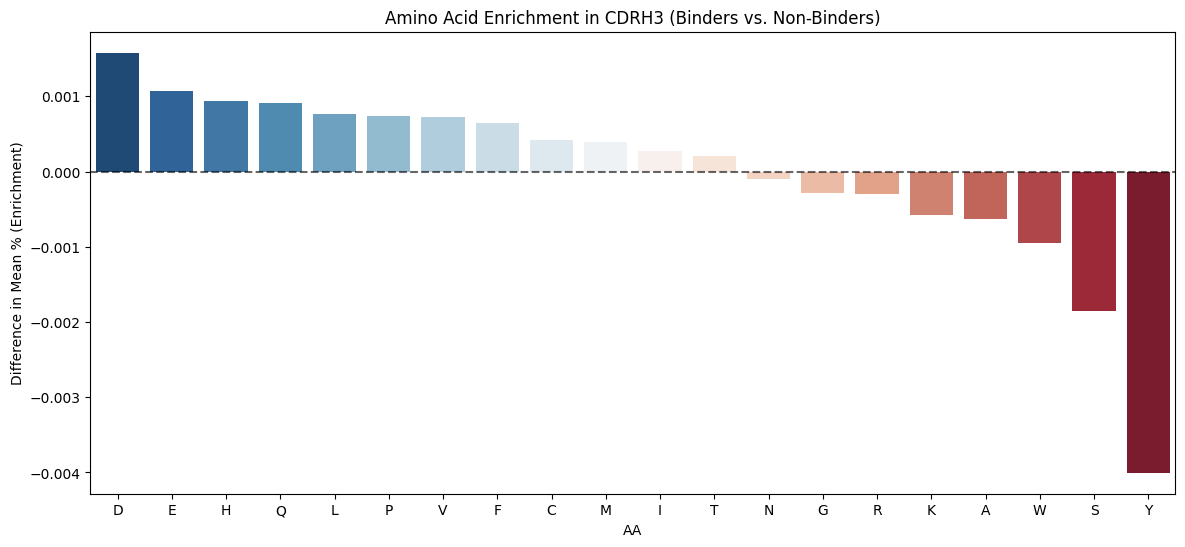

In [ ]:


# 2. Join features with labels
df_naive = labels[['is_binding_SARS-CoV2_WT']].join(naive_features, how='inner')

# 3. Identify CDRH3 amino acid percentage columns
aa_cols = [c for c in df_naive.columns if 'CDRH3_amino_acid_percentage_' in c]
amino_acids = [c.split('_')[-1] for c in aa_cols]

# 4. Calculate the Mean Difference (Binder - Non-Binder)
# We filter for group 1 (binders) and group 0 (non-binders)
binder_means = df_naive[df_naive['is_binding_SARS-CoV2_WT'] == 1][aa_cols].mean()
non_binder_means = df_naive[df_naive['is_binding_SARS-CoV2_WT'] == 0][aa_cols].mean()

# Compute the delta
enrichment = (binder_means - non_binder_means).reset_index()
enrichment.columns = ['Feature', 'Delta']
enrichment['AA'] = amino_acids
enrichment = enrichment.sort_values(by='Delta', ascending=False)

# 5. Plot the results
plt.figure(figsize=(14, 6))
sns.barplot(data=enrichment, x='AA', y='Delta', palette='RdBu_r')
plt.axhline(0, color='black', linestyle='--', alpha=0.6)
plt.title('Amino Acid Enrichment in CDRH3 (Binders vs. Non-Binders)')
plt.ylabel('Difference in Mean % (Enrichment)')
plt.show()